# **Going for Gold: Determining Which Attributes Predict Olympic Medals**

Austin Domer, Hanan Ali, and Peyton Hansen

## **Data Loading**

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_selection import SelectKBest, f_classif, chi2
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_curve, auc
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier, plot_tree


In [ ]:
df = pd.read_csv("./dataset_olympics.csv")
df.head()

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,NaN
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold
4,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,NaN


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 15 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   ID      70000 non-null  int64  
 1   Name    70000 non-null  object 
 2   Sex     70000 non-null  object 
 3   Age     67268 non-null  float64
 4   Height  53746 non-null  float64
 5   Weight  52899 non-null  float64
 6   Team    70000 non-null  object 
 7   NOC     70000 non-null  object 
 8   Games   70000 non-null  object 
 9   Year    70000 non-null  int64  
 10  Season  70000 non-null  object 
 11  City    70000 non-null  object 
 12  Sport   70000 non-null  object 
 13  Event   70000 non-null  object 
 14  Medal   9690 non-null   object 
dtypes: float64(3), int64(2), object(10)
memory usage: 8.0+ MB


## **Data Cleaning**

In [ ]:
df.duplicated().sum()

df.drop_duplicates(inplace = True)

df.duplicated().sum()

0

In [ ]:
data=df.drop(['ID', 'Name', 'Team', 'NOC','Games', 'Year','Season','City','Sport','Event'], axis=1)

In [ ]:
# Check null values in the dataset
print(data.isna().mean())

data = data.dropna(subset=['Age','Height','Weight','Sex'])

print(data.isna().mean())

Sex       0.000000
Age       0.038367
Height    0.228048
Weight    0.240142
Medal     0.860867
dtype: float64
Sex       0.000000
Age       0.000000
Height    0.000000
Weight    0.000000
Medal     0.864137
dtype: float64


# **Dropped Attribute Exploratory Analysis**

In [ ]:
# Event summary
df['Event'].value_counts()

Football Men's Football                                1738
Hockey Men's Hockey                                    1133
Ice Hockey Men's Ice Hockey                            1009
Basketball Men's Basketball                             921
Water Polo Men's Water Polo                             911
                                                       ... 
Archery Men's Pole Archery, Small Birds, Individual       1
Archery Men's Target Archery, 33 metres, Individual       1
Archery Men's Pole Archery, Small Birds, Team             1
Archery Men's Pole Archery, Large Birds, Team             1
Motorboating Mixed C-Class                                1
Name: Event, Length: 744, dtype: int64

In [ ]:
#Season summary
df['Season'].value_counts()

Summer    58084
Winter    11533
Name: Season, dtype: int64

In [ ]:
# Team summary
df['Team'].value_counts()

United States         4896
France                4539
Italy                 4010
Great Britain         3248
Canada                2536
                      ... 
Scram                    1
Hungaria                 1
Pigoule                  1
Hurlingham-2             1
Sydney Rowing Club       1
Name: Team, Length: 827, dtype: int64

In [ ]:
# Top 15 participating countries
top_countries = df.Team.value_counts().sort_values(ascending=False).head(15)
top_countries

United States    4896
France           4539
Italy            4010
Great Britain    3248
Canada           2536
Australia        2235
Sweden           2043
Germany          1946
Spain            1836
Switzerland      1530
Brazil           1529
Hungary          1507
Netherlands      1443
Romania          1332
Belgium          1278
Name: Team, dtype: int64

**Gold Medals**

In [ ]:
# Countries with most Gold medals
gold_countries = df[(df.Medal == 'Gold')].Team
gold_countries = gold_countries.value_counts().head(20)
gold_countries

United States    709
Soviet Union     212
Italy            202
France           167
Great Britain    154
Germany          133
Canada           107
Australia         97
Hungary           94
Norway            82
Sweden            79
East Germany      73
Russia            72
Netherlands       58
Romania           46
China             44
Denmark           41
Cuba              39
Spain             38
West Germany      36
Name: Team, dtype: int64

In [ ]:
#Gold medalist DataFrame
goldMedals = df[(df.Medal == 'Gold')]
goldMedals.head()

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold
42,17,Paavo Johannes Aaltonen,M,28.0,175.0,64.0,Finland,FIN,1948 Summer,1948,Summer,London,Gymnastics,Gymnastics Men's Team All-Around,Gold
44,17,Paavo Johannes Aaltonen,M,28.0,175.0,64.0,Finland,FIN,1948 Summer,1948,Summer,London,Gymnastics,Gymnastics Men's Horse Vault,Gold
48,17,Paavo Johannes Aaltonen,M,28.0,175.0,64.0,Finland,FIN,1948 Summer,1948,Summer,London,Gymnastics,Gymnastics Men's Pommelled Horse,Gold
60,20,Kjetil Andr Aamodt,M,20.0,176.0,85.0,Norway,NOR,1992 Winter,1992,Winter,Albertville,Alpine Skiing,Alpine Skiing Men's Super G,Gold


**Top Teams with Gold Medals**

In [ ]:
goldMedals=goldMedals.value_counts().reset_index(name='index')

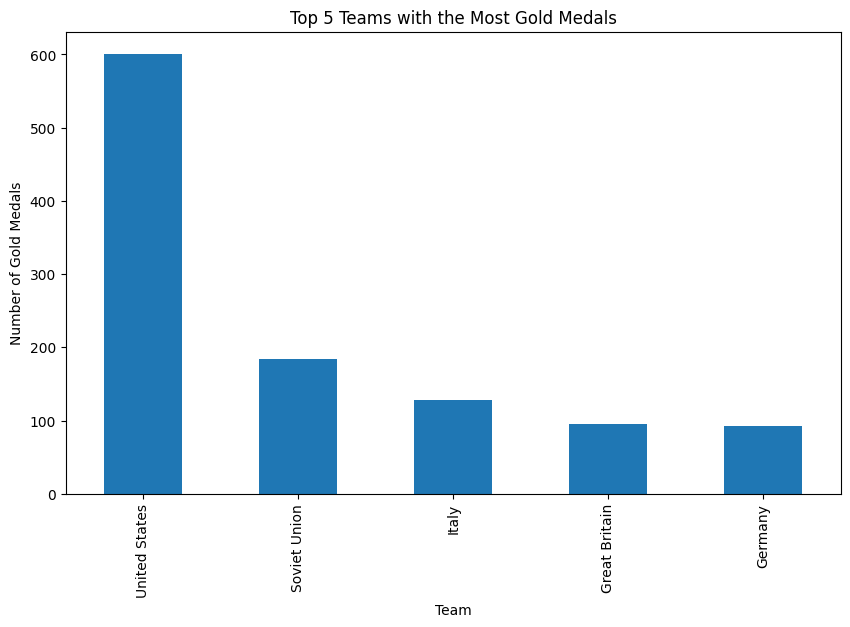

In [ ]:
#Top 5 countries
gold_counts = goldMedals['Team'].value_counts().nlargest(5)
#print(gold_counts)

plt.figure(figsize=(10, 6))
gold_counts.plot(kind='bar')
plt.title('Top 5 Teams with the Most Gold Medals')
plt.xlabel('Team')
plt.ylabel('Number of Gold Medals')
plt.show()

# **Kept Attribute Exploratory Analysis**

**Correlation between Medals and other features (Age, Weight, and Height)**

The correlation between Age and Medal is: nan


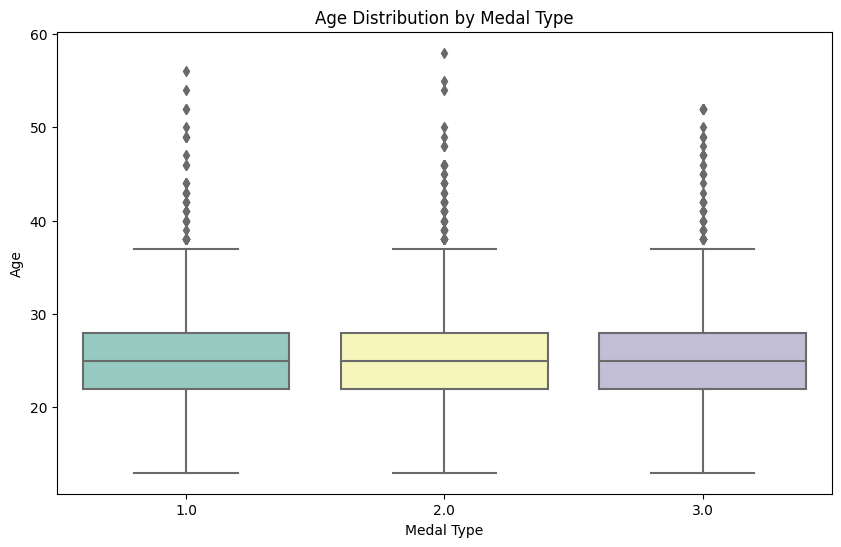

The correlation between Weight and Medal is: nan


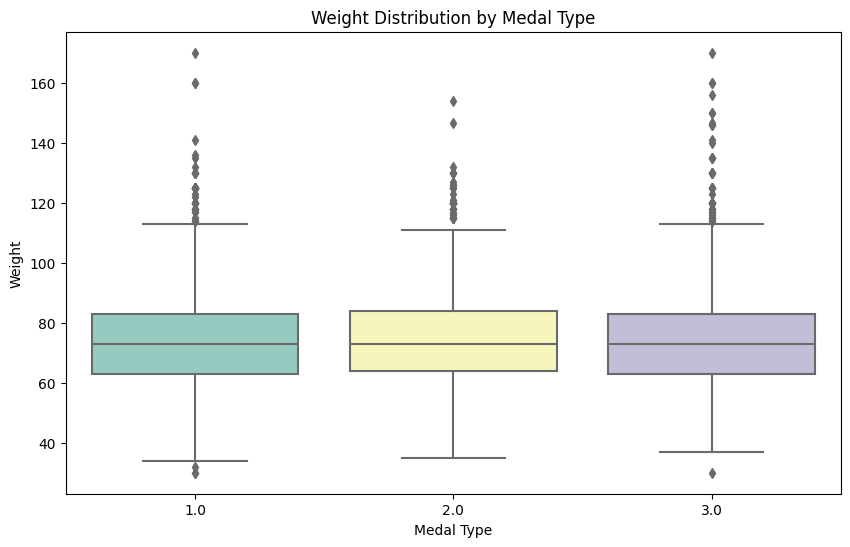

The correlation between Height and Medal is: nan


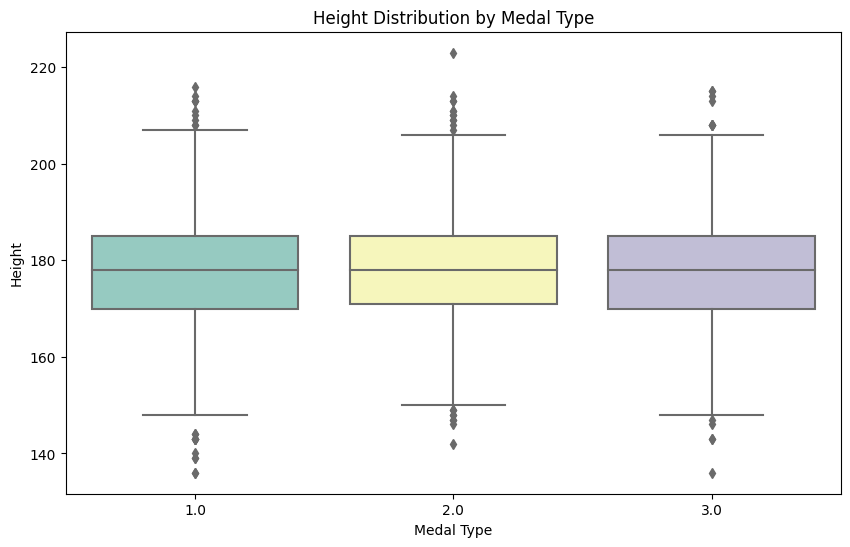

In [ ]:
# Correlation of numerical features and Medals
medal_mapping = {'Gold': 1, 'Silver': 2, 'Bronze': 3, '': 0}
data['Medal'] = data['Medal'].map(medal_mapping)

# Calculate the correlation between Age and Medal
age = data['Age'].corr(data['Medal'].map(medal_mapping))

print(f"The correlation between Age and Medal is: {age}")

plt.figure(figsize=(10, 6))
sns.boxplot(x='Medal', y='Age', data=data, palette='Set3')
plt.title('Age Distribution by Medal Type')
plt.xlabel('Medal Type')
plt.ylabel('Age')
plt.show()

# Calculate the correlation between Weight and Medal
weight = data['Weight'].corr(data['Medal'].map(medal_mapping))

print(f"The correlation between Weight and Medal is: {weight}")

plt.figure(figsize=(10, 6))
sns.boxplot(x='Medal', y='Weight', data=data, palette='Set3')
plt.title('Weight Distribution by Medal Type')
plt.xlabel('Medal Type')
plt.ylabel('Weight')
plt.show()

# Calculate the correlation between Height and Medal
height = data['Height'].corr(data['Medal'].map(medal_mapping))

print(f"The correlation between Height and Medal is: {height}")

plt.figure(figsize=(10, 6))
sns.boxplot(x='Medal', y='Height', data=data, palette='Set3')
plt.title('Height Distribution by Medal Type')
plt.xlabel('Medal Type')
plt.ylabel('Height')
plt.show()

In [ ]:
# Change Medal type
data['Medal'] = data['Medal'].astype(str)

In [ ]:
# Medal column in binary
data['Medal'] = data['Medal'].apply(lambda x: 1 if str(x) != 'nan' else 0)
data.head()

,Sex,Age,Height,Weight,Medal
0,M,24.0,180.0,80.0,0
1,M,23.0,170.0,60.0,0
4,F,21.0,185.0,82.0,0
5,F,21.0,185.0,82.0,0
6,F,25.0,185.0,82.0,0


In [ ]:
# Participants' gender distribution
genders = data.Sex.value_counts()
genders

M    36125
F    16141
Name: Sex, dtype: int64

In [ ]:
avBySex = data[['Sex', 'Medal', 'Height', 'Weight']]
result = avBySex.groupby(['Sex', 'Medal']).mean().astype(int)
result

Height  Weight
Sex Medal                
F   0         167      59
    1         170      62
M   0         178      75
    1         181      79

Deleting 'Sex' since the distribution between M and F is ~equal.

In [ ]:
data = data.drop(['Sex'], axis=1)

In [ ]:
#Age distribution of participants
age_groups = data.Age.value_counts().sort_values(ascending=False).head(15)
age_groups


23.0    4518
24.0    4394
22.0    4272
25.0    4137
21.0    4054
26.0    3621
27.0    3332
20.0    3034
28.0    2876
29.0    2350
19.0    2343
30.0    1845
18.0    1582
31.0    1474
32.0    1197
Name: Age, dtype: int64

In [ ]:
# Height distribution of participants
height_groups = data.Height.value_counts().sort_values(ascending=False).head(15)
height_groups

180.0    3210
170.0    3128
175.0    2740
178.0    2620
183.0    2155
172.0    2069
173.0    1954
168.0    1845
185.0    1743
165.0    1680
176.0    1601
182.0    1491
174.0    1464
167.0    1299
177.0    1232
Name: Height, dtype: int64

In [ ]:
# Weight distribution of participants
weight_groups = data.Weight.value_counts().sort_values(ascending=False).head(15)
weight_groups

70.0    2544
75.0    2054
60.0    1954
68.0    1831
65.0    1755
72.0    1693
73.0    1622
64.0    1600
80.0    1549
63.0    1450
67.0    1334
62.0    1267
58.0    1250
74.0    1208
69.0    1194
Name: Weight, dtype: int64

<ipython-input-15-f1359608c794>:6: MatplotlibDeprecationWarning: Auto-removal of overlapping axes is deprecated since 3.6 and will be removed two minor releases later; explicitly call ax.remove() as needed.
  plt.subplot(1, 3, 1)


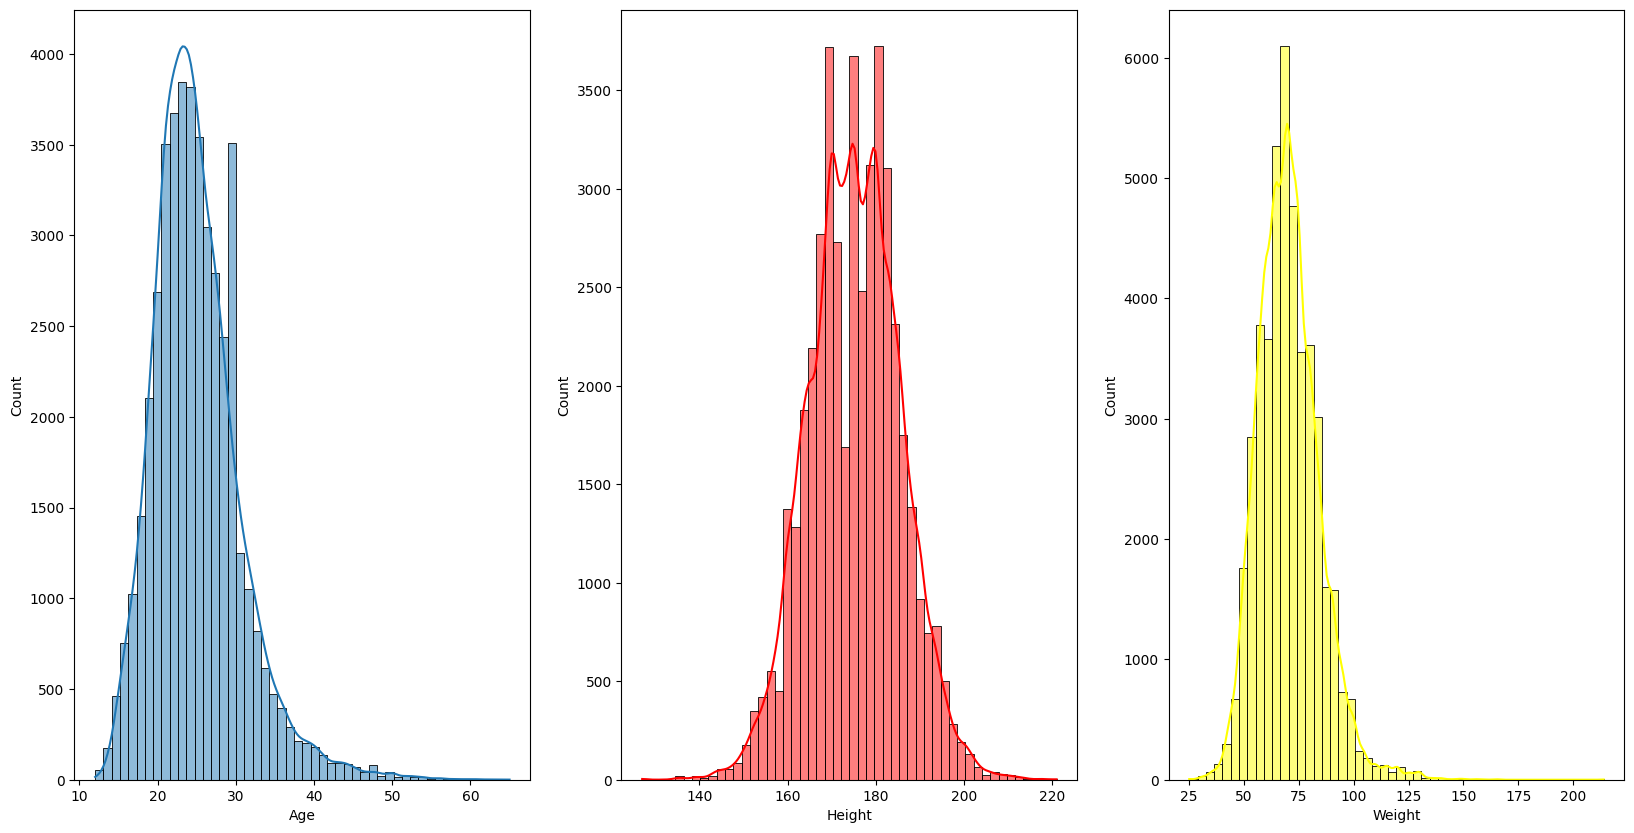

In [ ]:
# Correlation with Medaling by age, height, weight
Medalists = data[data['Medal'] == 0]

plt.figure(figsize=(20, 10))
plt.title('Distribution of Medalists')
plt.subplot(1, 3, 1)
sns.histplot(Medalists['Age'], kde=True, bins=50)
plt.subplot(1, 3, 2)
sns.histplot(Medalists['Height'], kde=True, bins=50, color='red')
plt.subplot(1, 3, 3)
sns.histplot(Medalists['Weight'], kde=True, bins=50, color='yellow')
plt.show()

In [ ]:
# Medal summary
data['Medal'].value_counts()

0    45165
1     7101
Name: Medal, dtype: int64

# **Univariate Analysis**

**Distribution between attributes and medaling**

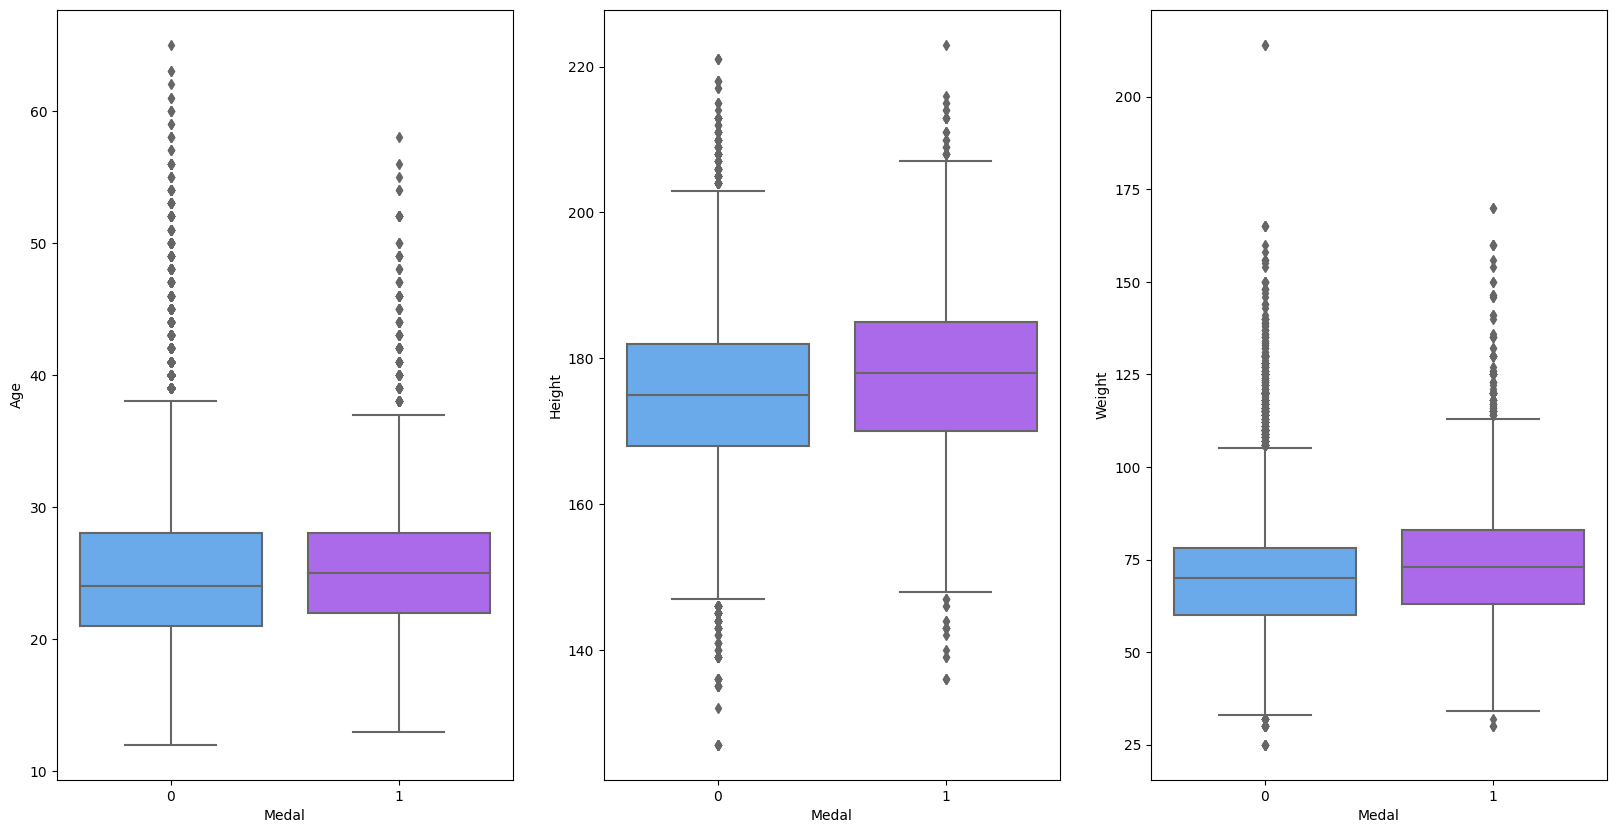

In [ ]:
# Medalists by age, height, weight
plt.figure(figsize=(20, 10))
plt.subplot(1, 3, 1)
sns.boxplot(x='Medal', y='Age', data=data, palette='cool')
plt.subplot(1, 3, 2)
sns.boxplot(x='Medal', y='Height', data=data, palette='cool')
plt.subplot(1, 3, 3)
sns.boxplot(x='Medal', y='Weight', data=data, palette='cool')
plt.show()

# **Bivariate Analysis**

array([[<Axes: xlabel='Age', ylabel='Age'>,
        <Axes: xlabel='Height', ylabel='Age'>,
        <Axes: xlabel='Weight', ylabel='Age'>],
       [<Axes: xlabel='Age', ylabel='Height'>,
        <Axes: xlabel='Height', ylabel='Height'>,
        <Axes: xlabel='Weight', ylabel='Height'>],
       [<Axes: xlabel='Age', ylabel='Weight'>,
        <Axes: xlabel='Height', ylabel='Weight'>,
        <Axes: xlabel='Weight', ylabel='Weight'>]], dtype=object)

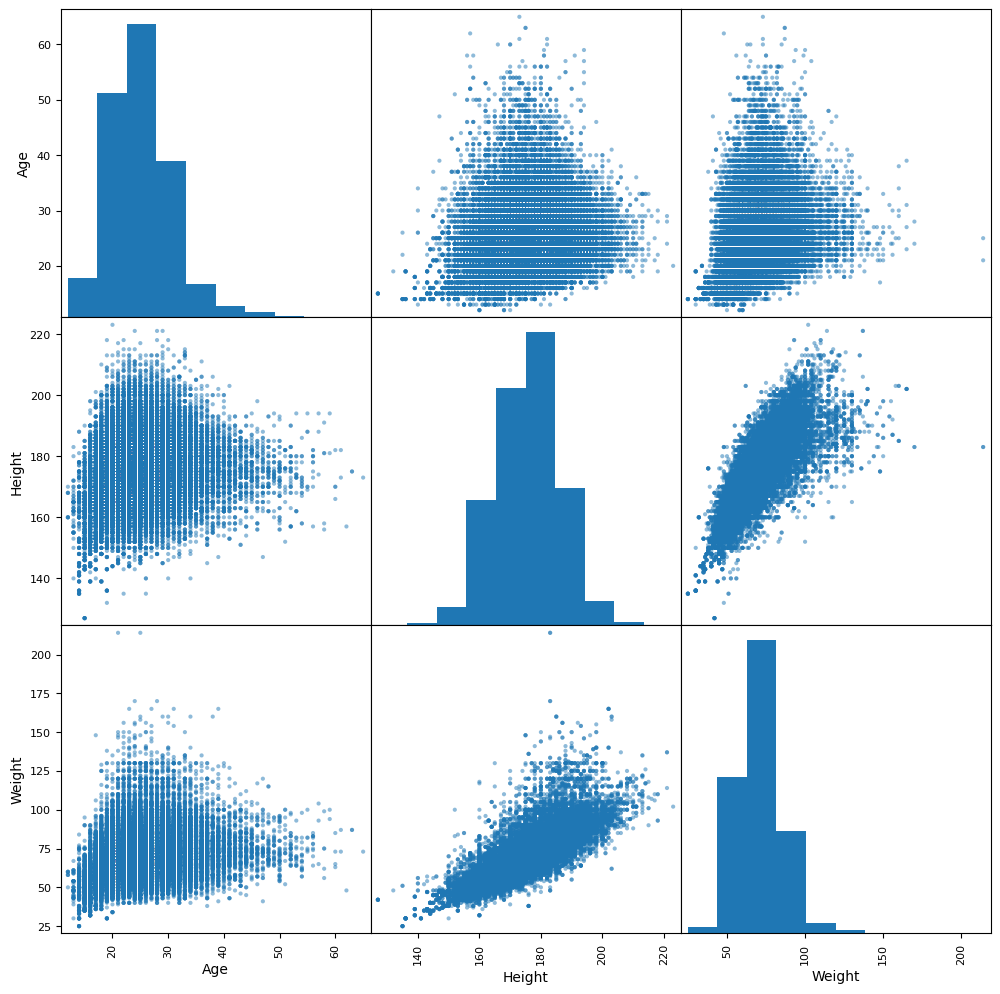

In [ ]:
#Scatter plot matrix
noMedal = data[['Age','Height','Weight']]
pd.plotting.scatter_matrix(noMedal, alpha=0.5, figsize=(12, 12), ax=None, grid=False, diagonal='hist', marker='.', density_kwds=None, hist_kwds=None, range_padding=0.05,)

# **Preparing the Data for Modeling**

In [ ]:
#Creating binary features
def binary_col(df, columns, values):
  df = df.copy()
  for column, value in zip(columns, values):
    df[column] = df[column].apply(lambda x: 1 if x == value else 0)
  return df

def categorical_binary(df, columns, values):
  df = df.copy()
  for column, value in zip(columns, values):
    dummy = pd.get_dummies(df[column], prefix=value)
    df = pd.concat([df, dummy], axis=1)
    df = df.drop(column, axis=1)
  return df



# **Feature Selection**

In [ ]:
# Split data
y = data['Medal'].values
X = data.drop('Medal', axis=1).values

In [ ]:
# Chi-squared test to select top 10 features
best = SelectKBest(score_func=chi2, k='all')

In [ ]:
fit = best.fit(X,y)

NameError: ignored

In [ ]:
scores = pd.DataFrame(fit.scores_)
cal_columns = pd.DataFrame(X.columns)

In [ ]:
full_scores=pd.concat([cal_columns, scores], axis=1)
full_scores.columns=['Feature', 'Score']
print(full_scores.nlargest(11, 'Score'))

  Feature        Score
2  Weight  1071.792417
1  Height   277.232270
0     Age    49.449603


In [ ]:
y=data['Medal'].values
X=data.drop(['Medal'], axis=1).values

train_x, test_x, train_y, test_y = train_test_split(X, y, test_size=0.4, random_state=1)

In [ ]:
# Linear Regression

line=LinearRegression()
line.fit(train_x, train_y)
y_pred = line.predict(test_x)
mae= mean_absolute_error(test_y, y_pred)
rmse=mean_squared_error(test_y, y_pred, squared=False)
r2=r2_score(test_y, y_pred)

print("The model performance for testing set:")
print(f'MAE is {round(mae, 3)}')
print(f'RMSE is {round(rmse, 3)}')
print(f'R2 Score is {round(r2*100, 2)}%')

The model performance for testing set:
MAE is 0.233
RMSE is 0.342
R2 Score is 0.99%


# **Predictive Models**

In [ ]:
y=data['Medal'].values
X=data.drop(['Medal'], axis=1).values

train_x, test_x, train_y, test_y = train_test_split(X, y, test_size=0.4, random_state=1)

In [ ]:
#Feature and data scaling
scaler=MinMaxScaler()
train_x=scaler.fit_transform(train_x)
test_x=scaler.transform(test_x)

In [ ]:
# Logistic Regression

logistic = 'LogisticRegression'
lr=LogisticRegression(random_state=1, max_iter=1000)
lr.fit(train_x, train_y)
lr_predict=lr.predict(test_x)
lr_matrix=confusion_matrix(test_y, lr_predict)
lr_accuracy=accuracy_score(test_y, lr_predict)
print(f"Confusion Matrix {lr_matrix}")
print("Accuracy:", round(lr_accuracy*100, 2), '\n')
print(classification_report(test_y, lr_predict))

Confusion Matrix [[18042     0]
 [ 2865     0]]
Accuracy: 86.3 

              precision    recall  f1-score   support

           0       0.86      1.00      0.93     18042
           1       0.00      0.00      0.00      2865

    accuracy                           0.86     20907
   macro avg       0.43      0.50      0.46     20907
weighted avg       0.74      0.86      0.80     20907



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


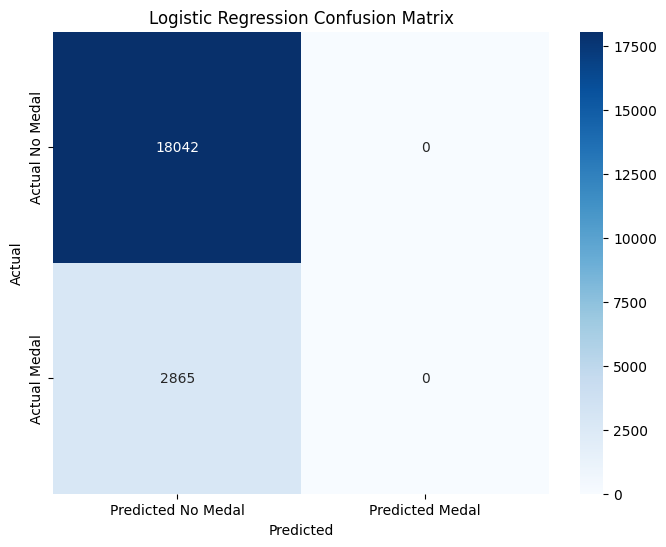

In [ ]:
lr_matrix = confusion_matrix(test_y, lr_predict)

plt.figure(figsize=(8, 6))
sns.heatmap(lr_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted No Medal', 'Predicted Medal'],
            yticklabels=['Actual No Medal', 'Actual Medal'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Logistic Regression Confusion Matrix')
plt.show()


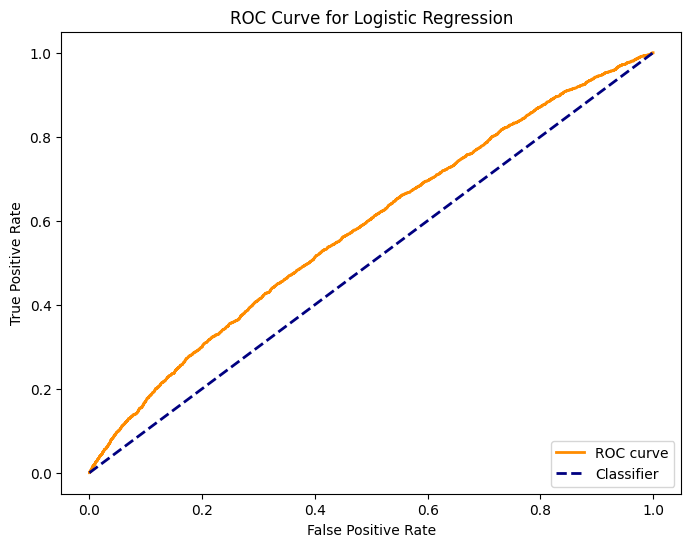

In [ ]:
#Calculate ROC Curve

lr_probs = lr.predict_proba(test_x)[:, 1]

fpr, tpr, thresholds = roc_curve(test_y, lr_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, label='Classifier', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Logistic Regression')
plt.legend(loc="lower right")
plt.show()


In [ ]:
# Decision Tree

decisiontree = 'DecisionTreeClassifier'
tree = DecisionTreeClassifier(criterion = 'entropy', random_state=10, max_depth=3)
tree.fit(train_x, train_y)
tree_predict=tree.predict(test_x)
tree_matrix=confusion_matrix(test_y, tree_predict)
tree_accuracy=accuracy_score(test_y, tree_predict)
print("Confusion Matrix")
print(tree_matrix)
print("\n")
print("Accuracy of Decision Tree Classifier:", round(tree_accuracy*100, 2), "\n")
print(classification_report(test_y, tree_predict))

Confusion Matrix
[[18042     0]
 [ 2865     0]]


Accuracy of Decision Tree Classifier: 86.3 

              precision    recall  f1-score   support

           0       0.86      1.00      0.93     18042
           1       0.00      0.00      0.00      2865

    accuracy                           0.86     20907
   macro avg       0.43      0.50      0.46     20907
weighted avg       0.74      0.86      0.80     20907



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


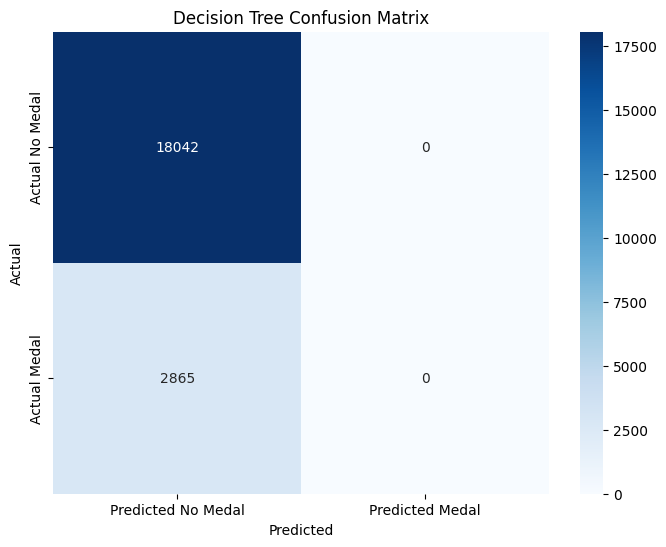

In [ ]:
tree_matrix = confusion_matrix(test_y, tree_predict)

plt.figure(figsize=(8, 6))
sns.heatmap(tree_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted No Medal', 'Predicted Medal'],
            yticklabels=['Actual No Medal', 'Actual Medal'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Decision Tree Confusion Matrix')
plt.show()

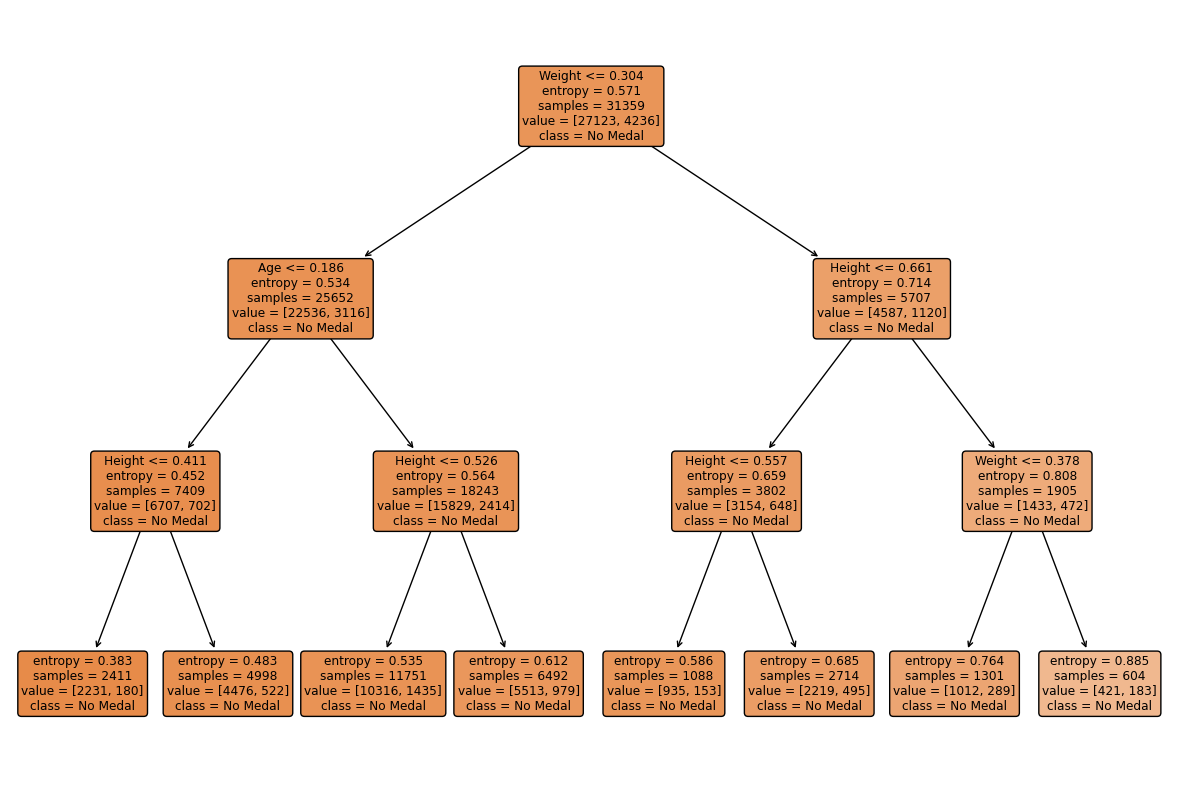

In [ ]:
plt.figure(figsize=(15, 10))
plot_tree(tree, feature_names=data.drop(['Medal'], axis=1).columns, class_names=['No Medal', 'Medal'], filled=True, rounded=True)
plt.show()

In [ ]:
# Naive Bayes

bayes = 'NaiveBayes'
naivebayes=MultinomialNB()
naivebayes.fit(train_x, train_y)
naivebayes_predict=naivebayes.predict(test_x)
naivebayes_matrix=confusion_matrix(test_y, naivebayes_predict)
naivebayes_accuracy=accuracy_score(test_y, naivebayes_predict)
print("Confusion Matrix")
print(naivebayes_matrix, '\n')
print("Accuracy of Naive Bayes: ", round(naivebayes_accuracy*100, 2), '\n')
print(classification_report(test_y, naivebayes_predict))

Confusion Matrix
[[18042     0]
 [ 2865     0]] 

Accuracy of Naive Bayes:  86.3 

              precision    recall  f1-score   support

           0       0.86      1.00      0.93     18042
           1       0.00      0.00      0.00      2865

    accuracy                           0.86     20907
   macro avg       0.43      0.50      0.46     20907
weighted avg       0.74      0.86      0.80     20907



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


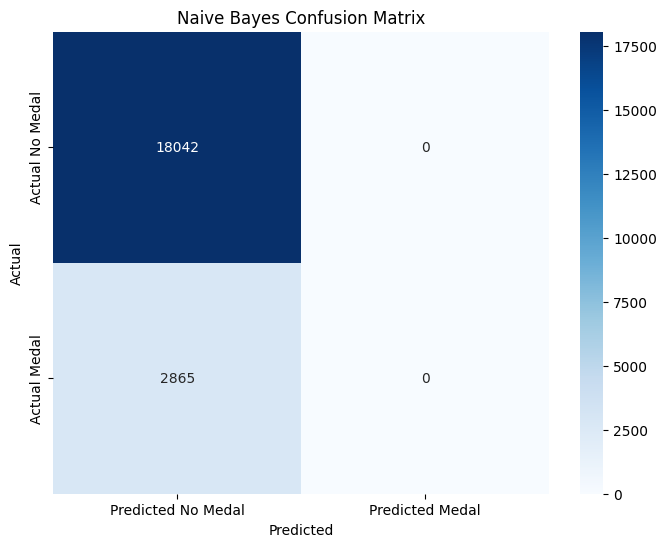

In [ ]:
naivebayes_matrix = confusion_matrix(test_y, naivebayes_predict)

plt.figure(figsize=(8, 6))
sns.heatmap(naivebayes_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted No Medal', 'Predicted Medal'],
            yticklabels=['Actual No Medal', 'Actual Medal'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Naive Bayes Confusion Matrix')
plt.show()

**Which model is a better fit for the data?**

In [ ]:
model = pd.DataFrame({'Model': ['Logistic Regression', 'Decision Tree', 'Naive Bayes'],
                      'Accuracy': [round(lr_accuracy*100, 2), round(tree_accuracy*100, 2), round(naivebayes_accuracy*100, 2)]})
model

,Model,Accuracy
0,Logistic Regression,86.30
1,Decision Tree,82.24
2,Naive Bayes,86.30
